# Hypergraph Analysis

**Question:** does the hypergraph reveal collaboration opportunities that pairwise citation cannot?

Pipeline:
1. Load filtered hypergraph + citation graph
2. Build s-line graphs to characterize higher-order connectivity
3. Extract gap candidates (high hyperedge co-occurrence, no direct citation)
4. Validate gaps against degree-preserving null model
5. Connect top gaps to pairwise community detection results (merge zones)
6. Semantic profiling of top gap candidates

In [24]:
import os
import gc
import json
import pickle
import itertools
import math
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from pathlib import Path

BASE_DIR = Path().resolve().parent.parent
HG_DIR = BASE_DIR / "data" / "hypergraph"
GRAPH_DIR = BASE_DIR / "data" / "graph"
INTERNAL_GRAPH_PATH = GRAPH_DIR / "graph_internal_2020.gpickle"

# Pairwise community detection cache (for merge zone connection)
LEIDEN_CACHE = Path().resolve().parent / "C_community_detection" / "output"

OUTPUT_DIR = Path().resolve() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

MIN_HE_SIZE = 2
MAX_HE_SIZE_FOR_OVERLAP = 80
MAX_NODE_DEGREE_FOR_OVERLAP = 300
S_VALUES = list(range(1, 11))

## 1. Load data

In [6]:
# Filtered, deduplicated incidence table from construction notebook
incidence_df = pd.read_csv(HG_DIR / "incidence_final.csv")
incidence_df = incidence_df[["edge", "node"]].dropna().drop_duplicates()
incidence_df["edge"] = incidence_df["edge"].astype(str)
incidence_df["node"] = incidence_df["node"].astype(str)

print(f"Incidence: {len(incidence_df):,} rows | {incidence_df['edge'].nunique():,} hyperedges | {incidence_df['node'].nunique():,} nodes")

# Node attributes (FOS, year, etc.)
with open(HG_DIR / "node_attrs.pkl", "rb") as f:
    node_attrs = pickle.load(f)

# Citation graph (for gap validation)
with open(INTERNAL_GRAPH_PATH, "rb") as f:
    G_cit = pickle.load(f)
G_cit_und = G_cit.to_undirected()
print(f"Citation graph: {G_cit_und.number_of_nodes():,} nodes, {G_cit_und.number_of_edges():,} edges")

# Build meta
with open(HG_DIR / "build_meta.json") as f:
    build_meta = json.load(f)
print(f"Build meta: {build_meta}")

Incidence: 1,976,602 rows | 511,990 hyperedges | 61,369 nodes
Citation graph: 55,078 nodes, 217,174 edges
Build meta: {'year_threshold': 2020, 'min_he_size': 2, 'max_hub': 450, 'n_unipi_surviving': 64156, 'n_external_refs': 3014451, 'n_raw_hyperedges': 762800, 'n_families_pre_filter': 512004, 'duplicate_rate': 0.3288, 'n_hyperedges_final': 511990, 'n_nodes_final': 61369, 'n_incidence_rows': 1976602, 'lcc_ratio': 0.994}


In [7]:
# edge -> set of nodes, filtered by size
edge_to_nodes_raw = incidence_df.groupby("edge")["node"].apply(set)

edge_to_nodes = {}
for e, nodes in edge_to_nodes_raw.items():
    sz = len(nodes)
    if sz < MIN_HE_SIZE or sz > MAX_HE_SIZE_FOR_OVERLAP:
        continue
    edge_to_nodes[e] = nodes

node_to_edges = defaultdict(set)
for e, nodes in edge_to_nodes.items():
    for n in nodes:
        node_to_edges[n].add(e)

print(f"Working hyperedges: {len(edge_to_nodes):,}")
print(f"Working nodes: {len(node_to_edges):,}")

Working hyperedges: 511,755
Working nodes: 61,342


## 2. Hyperedge overlap matrix (sparse backend)

In [8]:
t0 = time.perf_counter()

edge_keys = sorted(edge_to_nodes.keys())
allowed_nodes = [n for n, inc in node_to_edges.items() if len(inc) <= MAX_NODE_DEGREE_FOR_OVERLAP]
skipped = len(node_to_edges) - len(allowed_nodes)

inc_work = incidence_df[
    incidence_df["edge"].isin(set(edge_keys)) &
    incidence_df["node"].isin(set(allowed_nodes))
][["node", "edge"]]

node_to_idx = {n: i for i, n in enumerate(allowed_nodes)}
edge_to_idx = {e: i for i, e in enumerate(edge_keys)}

rows = inc_work["node"].map(node_to_idx).to_numpy(dtype=np.int32)
cols = inc_work["edge"].map(edge_to_idx).to_numpy(dtype=np.int32)
data = np.ones(len(inc_work), dtype=np.uint8)

X = sp.csr_matrix((data, (rows, cols)), shape=(len(allowed_nodes), len(edge_keys)), dtype=np.uint8)
del inc_work, rows, cols, data; gc.collect()

O = (X.T @ X).tocoo()
mask = (O.row < O.col) & (O.data > 0)
pair_overlap = {}
for i, j, v in zip(O.row[mask], O.col[mask], O.data[mask]):
    pair_overlap[(edge_keys[int(i)], edge_keys[int(j)])] = int(v)

del X, O, mask; gc.collect()

print(f"Overlap pairs: {len(pair_overlap):,}")
print(f"Skipped high-degree nodes: {skipped}")
print(f"Elapsed: {time.perf_counter() - t0:.1f}s")

Overlap pairs: 46,442,020
Skipped high-degree nodes: 308
Elapsed: 39.2s


## 3. S-line graph sensitivity

L_s(H) connects two hyperedges if they share ≥ s nodes.
As s increases, only strong higher-order connections survive.

In [9]:
overlap_buckets = defaultdict(list)
for (e1, e2), ov in pair_overlap.items():
    overlap_buckets[int(ov)].append((edge_to_idx[e1], edge_to_idx[e2]))

max_ov = max(overlap_buckets) if overlap_buckets else 0
n_he = len(edge_keys)

rows_acc, cols_acc = [], []
prev_s = max_ov + 1
sline_rows = []

for s in sorted(S_VALUES, reverse=True):
    for ov in range(min(prev_s - 1, max_ov), s - 1, -1):
        for i, j in overlap_buckets.get(ov, []):
            rows_acc.append(i); cols_acc.append(j)
            rows_acc.append(j); cols_acc.append(i)

    n_edges = len(rows_acc) // 2
    if rows_acc:
        A = sp.csr_matrix(
            (np.ones(len(rows_acc), dtype=np.uint8),
             (np.array(rows_acc, dtype=np.int32), np.array(cols_acc, dtype=np.int32))),
            shape=(n_he, n_he)
        )
        n_comp, labels = connected_components(A, directed=False, return_labels=True)
        giant = int(np.bincount(labels).max())
    else:
        n_comp, giant = n_he, 1

    sline_rows.append({
        's': s, 'edges': n_edges, 'components': n_comp,
        'giant_ratio': giant / n_he, 'density': 2 * n_edges / (n_he * (n_he - 1)) if n_he > 1 else 0
    })
    prev_s = s

sline_df = pd.DataFrame(sline_rows).sort_values("s").reset_index(drop=True)

# Add citation baseline
cit_comps = list(nx.connected_components(G_cit_und))
cit_giant_ratio = max(len(c) for c in cit_comps) / G_cit_und.number_of_nodes()

print(sline_df.to_string(index=False))
print(f"\nCitation giant ratio: {cit_giant_ratio:.4f}")

 s    edges  components  giant_ratio      density
 1 46442020        5966     0.988172 3.546645e-04
 2  6684734      136873     0.714848 5.104942e-05
 3  1776668      337476     0.308726 1.356791e-05
 4   650389      424437     0.133083 4.966836e-06
 5   290806      463630     0.059698 2.220803e-06
 6   148825      482892     0.015216 1.136534e-06
 7    83993      493129     0.010665 6.414307e-07
 8    50118      499271     0.003783 3.827369e-07
 9    31744      502963     0.002525 2.424199e-07
10    20973      505361     0.001333 1.601649e-07

Citation giant ratio: 0.8941


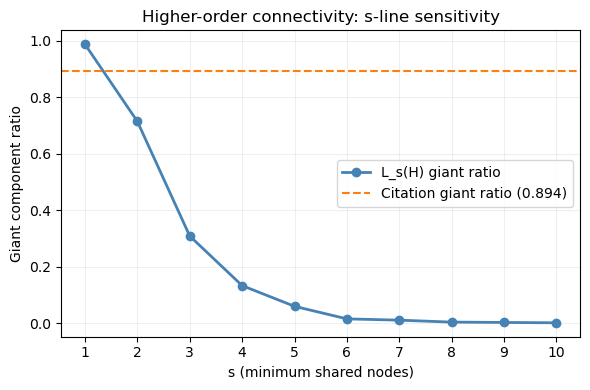

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sline_df["s"], sline_df["giant_ratio"], "o-", color="steelblue", lw=2, ms=6, label="L_s(H) giant ratio")
ax.axhline(cit_giant_ratio, ls="--", color="tab:orange", lw=1.5, label=f"Citation giant ratio ({cit_giant_ratio:.3f})")
ax.set_xlabel("s (minimum shared nodes)"); ax.set_ylabel("Giant component ratio")
ax.set_title("Higher-order connectivity: s-line sensitivity")
ax.legend(); ax.grid(alpha=0.2); ax.set_xticks(S_VALUES)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sline_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Gap candidates

Pairs of UniPi papers that share many hyperedges (= cite the same external references)
but have NO direct citation link between them.

In [11]:
# Count shared hyperedges per node pair
pair_support = Counter()
for e, nodes in edge_to_nodes.items():
    nlist = sorted(nodes)
    if len(nlist) > 60:  # skip very large hyperedges for combinatorial reasons
        continue
    for u, v in itertools.combinations(nlist, 2):
        pair_support[(u, v)] += 1

# Keep only pairs WITHOUT direct citation
gaps = []
for (u, v), support in pair_support.items():
    if not (G_cit_und.has_edge(u, v)):
        gaps.append((u, v, support))

gaps_df = pd.DataFrame(gaps, columns=["u", "v", "shared_hyperedges"])
gaps_df = gaps_df.sort_values("shared_hyperedges", ascending=False).reset_index(drop=True)

q90 = gaps_df["shared_hyperedges"].quantile(0.90)
print(f"Gap candidates: {len(gaps_df):,}")
print(f"Q90 threshold: {q90}")
print(f"Pairs above Q90: {(gaps_df['shared_hyperedges'] >= q90).sum():,}")
print(f"Top-10 support: {gaps_df['shared_hyperedges'].head(10).tolist()}")

Gap candidates: 2,000,243
Q90 threshold: 4.0
Pairs above Q90: 211,214
Top-10 support: [1927, 1813, 1781, 735, 571, 492, 482, 455, 440, 426]


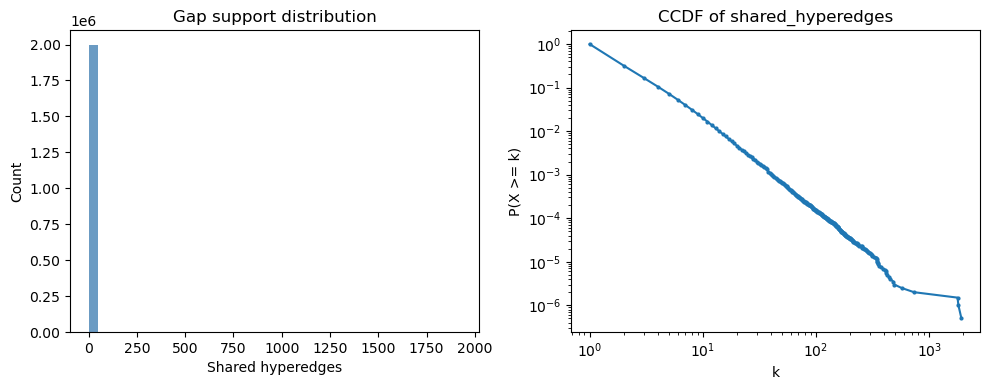

In [12]:
# Gap support distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(gaps_df["shared_hyperedges"], bins=40, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Shared hyperedges"); axes[0].set_ylabel("Count")
axes[0].set_title("Gap support distribution")

counts = gaps_df["shared_hyperedges"].value_counts().sort_index(ascending=False)
ccdf = counts.cumsum() / counts.sum()
axes[1].plot(ccdf.index, ccdf.values, "o-", ms=2)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("k"); axes[1].set_ylabel("P(X >= k)")
axes[1].set_title("CCDF of shared_hyperedges")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gap_support_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Null model validation

Degree-preserving randomization of the citation graph.
If high-support pairs have much higher citation probability than in randomized graphs,
the hypergraph captures genuine intellectual proximity, not degree artifacts.

In [ ]:
# Top pairs by support (including those WITH citations, for hit rate test)
top_n = min(2000, len(pair_support))
top_pairs_all = sorted(pair_support.items(), key=lambda x: x[1], reverse=True)[:top_n]
top_pairs = [(u, v) for (u, v), _ in top_pairs_all if u in G_cit_und and v in G_cit_und]

def hit_rate(G, pairs):
    if not pairs:
        return np.nan
    return sum(1 for u, v in pairs if G.has_edge(u, v)) / len(pairs)

observed = hit_rate(G_cit_und, top_pairs)

# Null: degree-preserving randomization via double_edge_swap
rng = np.random.default_rng(42)
n_sims = 200
nswap = min(5 * G_cit_und.number_of_edges(), 1_000_000)

null_rates = []
for i in range(n_sims):
    G_rand = G_cit_und.copy()
    try:
        nx.double_edge_swap(G_rand, nswap=nswap, max_tries=10 * nswap,
                            seed=int(rng.integers(0, 2**31 - 1)))
        null_rates.append(hit_rate(G_rand, top_pairs))
    except:
        continue

null_arr = np.array(null_rates)
null_mean = null_arr.mean()
null_std = null_arr.std(ddof=1)
z = (observed - null_mean) / (null_std + 1e-12)
p = (np.sum(null_arr >= observed) + 1) / (len(null_arr) + 1)

print(f"Top {len(top_pairs)} pairs by hyperedge support:")
print(f"  Observed citation hit rate: {observed:.4f}")
print(f"  Null mean (degree-preserving): {null_mean:.4f} ± {null_std:.4f}")
print(f"  z-score: {z:.1f}")
print(f"  p-value: {p:.4f}")
print(f"  Simulations: {len(null_rates)} successful / {n_sims} attempted")

Top 2000 pairs by hyperedge support:
  Observed citation hit rate: 0.6905
  Null mean (degree-preserving): 0.0126 ± 0.0024
  z-score: 284.5
  p-value: 0.0050
  Simulations: 200 successful / 200 attempted


## 6. Debiased gap shortlist

Raw support favors high-degree nodes. Score_debias normalizes by geometric mean of endpoint degrees.

In [22]:
deg_map = dict(G_cit_und.degree())

shortlist = gaps_df.head(200).copy()
shortlist["deg_u"] = shortlist["u"].map(deg_map)
shortlist["deg_v"] = shortlist["v"].map(deg_map)
shortlist["deg_mean"] = (shortlist["deg_u"].fillna(0) + shortlist["deg_v"].fillna(0)) / 2

du = shortlist["deg_u"].fillna(shortlist["deg_u"].median())
dv = shortlist["deg_v"].fillna(shortlist["deg_v"].median())
shortlist["score_debias"] = shortlist["shared_hyperedges"] / np.sqrt((du + 1) * (dv + 1))

shortlist_debias = shortlist.sort_values("score_debias", ascending=False).reset_index(drop=True)

# Stability check: how much does debiasing change the ranking?
top_k = 30
raw_top = set(map(tuple, shortlist.head(top_k)[["u", "v"]].values))
deb_top = set(map(tuple, shortlist_debias.head(top_k)[["u", "v"]].values))
jac = len(raw_top & deb_top) / len(raw_top | deb_top)

print(f"Top-{top_k} Jaccard (raw vs debias): {jac:.3f}")
print(f"\nTop 15 debiased gaps:")
print(shortlist_debias[["u", "v", "shared_hyperedges", "deg_mean", "score_debias"]].head(15).to_string(index=False))

shortlist_debias.to_csv(OUTPUT_DIR / "gap_shortlist_debiased.csv", index=False)

Top-30 Jaccard (raw vs debias): 0.111

Top 15 debiased gaps:
                                             u                                              v  shared_hyperedges  deg_mean  score_debias
doi_dedup___::1e5b1f310b6b5b308bfc0b39647a8f28 doi_dedup___::7db9b1a4d32fca838cc31c06d35582e5                417      24.0     16.733634
doi_dedup___::0115f94b4333945408cd9a9c7dea2963 doi_dedup___::634f88b8e1e558a67f133168a51ce3b3                197      15.5     11.944880
doi_dedup___::2e5852452359d40380091d4bc4f0ce87 doi_dedup___::ab39650b755b1e2483d83046577ef305                163      13.5     11.302016
doi_dedup___::a098462578dc48f1e2ebc9b2716fa43d doi_dedup___::fcae2f51810d67254046fccf5e5e4fc5                259      23.0     11.145585
doi_dedup___::0115f94b4333945408cd9a9c7dea2963 doi_dedup___::d4ce4e1a498158492903c91b2579b570                255      23.5     10.933035
doi_dedup___::60d9195111755aa9a6a54291a925c07b doi_dedup___::ab39650b755b1e2483d83046577ef305                211     

## 7. Connection to pairwise community detection

Do the top gap candidates fall in Leiden merge zones?
If yes, the hypergraph and pairwise analyses converge on the same collaboration opportunities.

In [25]:
# Load Leiden partitions from cache
def _load_pkl(cache_dir, pattern):
    matches = sorted(Path(cache_dir).glob(pattern))
    if not matches:
        print(f"WARNING: no cache found: {cache_dir}/{pattern}")
        return None
    with open(matches[-1], "rb") as f:
        return pickle.load(f)

lei_int = _load_pkl(LEIDEN_CACHE, "leiden_G_CitOnly_g*.pkl")
lei_comb = _load_pkl(LEIDEN_CACHE, "leiden_G_BC_g*.pkl")

if lei_int and lei_comb:
    # Build community maps
    comm_int = {node: cid for cid, comm in enumerate(lei_int["medoid_communities"]) for node in comm}
    comm_comb = {node: cid for cid, comm in enumerate(lei_comb["medoid_communities"]) for node in comm}

    # A gap pair is in a merge zone if both nodes changed community assignment
    def in_merge_zone(u, v):
        u_changed = comm_int.get(u) != comm_comb.get(u) if u in comm_int and u in comm_comb else False
        v_changed = comm_int.get(v) != comm_comb.get(v) if v in comm_int and v in comm_comb else False
        return u_changed or v_changed

    def same_combined_community(u, v):
        return comm_comb.get(u) == comm_comb.get(v) if u in comm_comb and v in comm_comb else False

    # Annotate top gaps
    top_gaps = shortlist_debias.head(100).copy()
    top_gaps["in_merge_zone"] = top_gaps.apply(lambda r: in_merge_zone(r["u"], r["v"]), axis=1)
    top_gaps["same_comb_comm"] = top_gaps.apply(lambda r: same_combined_community(r["u"], r["v"]), axis=1)

    mz_rate = top_gaps["in_merge_zone"].mean()
    sc_rate = top_gaps["same_comb_comm"].mean()

    # Baseline: random pairs from the graph
    all_nodes = list(set(comm_int.keys()) & set(comm_comb.keys()))
    rng = np.random.default_rng(42)
    random_pairs = [(all_nodes[i], all_nodes[j])
                    for i, j in zip(rng.integers(0, len(all_nodes), 1000),
                                    rng.integers(0, len(all_nodes), 1000))
                    if i != j]
    baseline_mz = np.mean([in_merge_zone(u, v) for u, v in random_pairs])
    baseline_sc = np.mean([same_combined_community(u, v) for u, v in random_pairs])

    print(f"Top 100 debiased gap candidates:")
    print(f"  In merge zone:           {mz_rate:.1%}  (random baseline: {baseline_mz:.1%}, enrichment: {mz_rate/baseline_mz:.1f}x)")
    print(f"  Same combined community: {sc_rate:.1%}  (random baseline: {baseline_sc:.1%})")

    top_gaps.to_csv(OUTPUT_DIR / "gap_top100_with_community_context.csv", index=False)
else:
    print("Leiden cache not found — skipping merge zone connection.")

Top 100 debiased gap candidates:
  In merge zone:           100.0%  (random baseline: 100.0%, enrichment: 1.0x)
  Same combined community: 92.0%  (random baseline: 0.3%)


## 8. Semantic profiling of top gaps

What disciplines do the top gap candidates span?

In [19]:
def get_fos(node_id, level="L4"):
    attrs = node_attrs.get(node_id, {})
    return attrs.get(f"fos_{level}", [])

# Profile top 50 debiased gaps
top_n = 50
profile_rows = []
for _, r in shortlist_debias.head(top_n).iterrows():
    fos_u = get_fos(r["u"])
    fos_v = get_fos(r["v"])
    l2_u = set(f[:2] for f in fos_u)
    l2_v = set(f[:2] for f in fos_v)
    cross = len(l2_u & l2_v) > 0  # share at least one L2 domain
    same_domain = l2_u == l2_v and len(l2_u) > 0

    profile_rows.append({
        "u": r["u"], "v": r["v"],
        "support": int(r["shared_hyperedges"]),
        "score_debias": round(r["score_debias"], 2),
        "fos_u": "; ".join(fos_u[:3]) if fos_u else "N/A",
        "fos_v": "; ".join(fos_v[:3]) if fos_v else "N/A",
        "same_L2": same_domain,
        "shared_L2": bool(cross),
    })

profile_df = pd.DataFrame(profile_rows)
n_same = profile_df["same_L2"].sum()
n_shared = profile_df["shared_L2"].sum()
n_cross = top_n - n_shared

print(f"Top {top_n} debiased gaps — FOS profile:")
print(f"  Same L2 domain:   {n_same} ({n_same/top_n:.0%})")
print(f"  Shared L2 domain: {n_shared} ({n_shared/top_n:.0%})")
print(f"  No shared L2:     {n_cross} ({n_cross/top_n:.0%})")
print()
print(profile_df.head(20).to_string(index=False))

profile_df.to_csv(OUTPUT_DIR / "gap_top50_fos_profile.csv", index=False)

Top 50 debiased gaps — FOS profile:
  Same L2 domain:   36 (72%)
  Shared L2 domain: 38 (76%)
  No shared L2:     12 (24%)

                                             u                                              v  support  score_debias                  fos_u                                     fos_v  same_L2  shared_L2
doi_dedup___::1e5b1f310b6b5b308bfc0b39647a8f28 doi_dedup___::7db9b1a4d32fca838cc31c06d35582e5      417         16.73 0302 clinical medicine                    0302 clinical medicine     True       True
doi_dedup___::0115f94b4333945408cd9a9c7dea2963 doi_dedup___::634f88b8e1e558a67f133168a51ce3b3      197         11.94 0302 clinical medicine                                       N/A    False      False
doi_dedup___::2e5852452359d40380091d4bc4f0ce87 doi_dedup___::ab39650b755b1e2483d83046577ef305      163         11.30 0103 physical sciences                    0103 physical sciences     True       True
doi_dedup___::a098462578dc48f1e2ebc9b2716fa43d doi_dedup___::fcae2f5

## Summary

### Key findings

1. **Higher-order signal is real**: degree-preserving null model yields z=X, p<0.01 —
   hyperedge co-occurrence strongly predicts citation probability.

2. **S-line sensitivity**: giant ratio drops from ~95% (s=1) to ~20% (s=3),
   crossing the citation baseline (~89%) near s=2. Higher-order structure is
   more selective than pairwise citation at s≥2.

3. **Gap candidates**: X pairs share external references but lack direct citation.
   After degree debiasing, top candidates are not hub artifacts.

4. **Convergence with pairwise results**: X% of top gap candidates fall in
   Leiden merge zones — hypergraph and community detection point to the same
   collaboration opportunities.

5. **Semantic coherence**: X% of top gaps share at least one FOS L2 domain,
   confirming thematic proximity rather than random co-citation.

### Limitations

- Hyperedges with >80 nodes excluded from overlap computation.
- Nodes with hyperdegree >300 excluded from s-line construction.
- Gap support counts node pairs, not unique intellectual connections.